MSE: 15367.074208590611
R2 Score: 0.9811284926406372


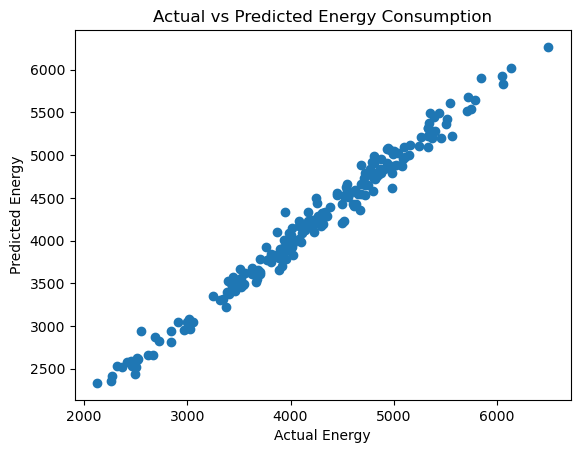

Predicted Energy Consumption: 3789.6718000000005


In [14]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# =========================
# 2. LOAD DATA
# =========================
df = pd.read_csv("energy_data.csv")

# =========================
# 3. FEATURES & TARGET
# =========================
X = df.drop("Energy Consumption", axis=1)
y = df["Energy Consumption"]

# =========================
# 4. PREPROCESSING
# =========================
categorical_features = ["Building Type", "Day of Week"]
numerical_features = ["Square Footage", "Number of Occupants", 
                      "Appliances Used", "Average Temperature"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(drop="first"), categorical_features)
])

# =========================
# 5. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 6. MODEL PIPELINE
# =========================
model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=200, random_state=42))
])

# =========================
# 7. TRAIN MODEL
# =========================
model.fit(X_train, y_train)

# =========================
# 8. PREDICTION
# =========================
y_pred = model.predict(X_test)

# =========================
# 9. EVALUATION
# =========================
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2 Score:", r2)

# =========================
# 10. VISUALIZATION
# =========================
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Energy")
plt.ylabel("Predicted Energy")
plt.title("Actual vs Predicted Energy Consumption")
plt.show()

# =========================
# 11. NEW PREDICTION
# =========================
new_data = pd.DataFrame({
    "Building Type": ["Residential"],
    "Square Footage": [30000],
    "Number of Occupants": [50],
    "Appliances Used": [20],
    "Average Temperature": [25],
    "Day of Week": ["Weekday"]
})

prediction = model.predict(new_data)
print("Predicted Energy Consumption:", prediction[0])